# StockVision — Hyperparameter Tuning

## Objective

Tune the **Random Forest** model for stock-direction prediction using **Optuna**.

### Prediction horizons
- **1D** — next trading day
- **5D** — next 5 trading days
- **20D** — next 20 trading days

### Validation strategy
- Chronological **80/20 train-test split**
- `TimeSeriesSplit` on the training portion only
- Final 20% test set remains untouched during hyperparameter optimization

### Models
- Default Random Forest
- Optuna-tuned Random Forest

The reusable implementation lives in `src/tune_models.py`. This notebook is intentionally focused on running the tuning pipeline and analyzing its results.


## 1. Imports

The notebook uses the reusable tuning function from `src/tune_models.py` instead of duplicating the Optuna and Random Forest implementation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import STOCKS, FEATURES
from src.train_models import HORIZONS
from src.tune_models import tune_models


## 2. Configuration

Stocks, features, and prediction horizons are taken from the central project configuration.


In [2]:
stocks = STOCKS
horizons = HORIZONS
features = FEATURES

N_TRIALS = 15

print("Stocks:", stocks)
print("Horizons:", horizons)
print("Number of features:", len(features))


Stocks: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
Horizons: ['1D', '5D', '20D']
Number of features: 18


## 3. Hyperparameter Tuning

The reusable `tune_models()` function performs the complete tuning workflow for all **8 stocks × 3 horizons**.

For every stock-horizon combination it:
1. Loads the corresponding ML-ready dataset.
2. Performs the chronological 80/20 split.
3. Keeps the final test set untouched.
4. Runs Optuna on the training data.
5. Uses `TimeSeriesSplit` as the validation strategy.
6. Optimizes mean CV accuracy.
7. Trains the tuned Random Forest on the training portion.
8. Evaluates the tuned model on the untouched test set.
9. Returns the tuned results, default RF results, and best parameters.


In [3]:
tuning_results = tune_models(n_trials=N_TRIALS)

tuned_results_df = tuning_results["tuned_results"]
default_rf_results_df = tuning_results["default_rf_results"]
best_params = tuning_results["best_params"]

print("Hyperparameter tuning completed successfully.")



Tuning Random Forest: AAPL - 1D
Training rows: 2316
Test rows: 579
Best CV accuracy: 0.5037
Best parameters: {'n_estimators': 91, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Test accuracy: 0.4525
Completed: AAPL - 1D

Tuning Random Forest: MSFT - 1D
Training rows: 2316
Test rows: 579
Best CV accuracy: 0.4922
Best parameters: {'n_estimators': 146, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Test accuracy: 0.4680
Completed: MSFT - 1D

Tuning Random Forest: NVDA - 1D
Training rows: 2316
Test rows: 579
Best CV accuracy: 0.4853
Best parameters: {'n_estimators': 91, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2'}
Test accuracy: 0.5302
Completed: NVDA - 1D

Tuning Random Forest: AMZN - 1D
Training rows: 2316
Test rows: 579
Best CV accuracy: 0.4917
Best parameters: {'n_estimators': 190, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sq

## 4. Returned Data Verification

Confirm that tuning produced results for every stock and horizon.


In [4]:
expected_rows = len(stocks) * len(horizons)

print("Expected stock-horizon combinations:", expected_rows)
print("Tuned result rows:", len(tuned_results_df))
print("Default RF result rows:", len(default_rf_results_df))
print("Best parameter entries:", len(best_params))

display(tuned_results_df.head())
display(default_rf_results_df.head())


Expected stock-horizon combinations: 24
Tuned result rows: 24
Default RF result rows: 24
Best parameter entries: 3


,Horizon,Stock,Accuracy,Precision,Recall,F1_Score,Tuned_CV_Mean,Tuned_CV_Std
0,1D,AAPL,0.452504,1.000000,0.009375,0.018576,0.503742,0.0
1,1D,AMZN,0.485320,0.500000,0.023490,0.044872,0.491652,0.0
2,1D,HDFCBANK.NS,0.502636,0.452632,0.156934,0.233062,0.512324,0.0
3,1D,INFY.NS,0.483304,0.464419,0.450909,0.457565,0.484155,0.0
4,1D,MSFT,0.468048,0.493724,0.386885,0.433824,0.492228,0.0


,Horizon,Stock,Default_Accuracy,Default_Precision,Default_Recall,Default_F1_Score,Default_CV_Mean,Default_CV_Std
0,1D,AAPL,0.457686,0.687500,0.034375,0.065476,0.487047,0.012213
1,1D,AMZN,0.519862,0.592593,0.214765,0.315271,0.480138,0.020484
2,1D,HDFCBANK.NS,0.490334,0.414894,0.142336,0.211957,0.505282,0.014589
3,1D,INFY.NS,0.511424,0.493088,0.389091,0.434959,0.468897,0.000830
4,1D,MSFT,0.488774,0.520548,0.373770,0.435115,0.470927,0.010202


## 5. Tuned Random Forest Results

The tuned model is evaluated on the independent chronological test set.

The `Tuned_CV_Mean` column contains the best mean Time-Series CV accuracy found by Optuna.


In [5]:
tuned_results_df

,Horizon,Stock,Accuracy,Precision,Recall,F1_Score,Tuned_CV_Mean,Tuned_CV_Std
0,1D,AAPL,0.452504,1.000000,0.009375,0.018576,0.503742,0.0
1,1D,AMZN,0.485320,0.500000,0.023490,0.044872,0.491652,0.0
2,1D,HDFCBANK.NS,0.502636,0.452632,0.156934,0.233062,0.512324,0.0
3,1D,INFY.NS,0.483304,0.464419,0.450909,0.457565,0.484155,0.0
4,1D,MSFT,0.468048,0.493724,0.386885,0.433824,0.492228,0.0
5,1D,NVDA,0.530225,0.536364,0.776316,0.634409,0.485320,0.0
6,1D,RELIANCE.NS,0.546573,0.546875,0.496454,0.520446,0.527582,0.0
7,1D,TCS.NS,0.478032,0.436364,0.564706,0.492308,0.504695,0.0
8,20D,AAPL,0.392361,0.814815,0.059946,0.111675,0.418551,0.0
9,20D,AMZN,0.550347,0.569091,0.934328,0.707345,0.518841,0.0


## 6. Best Hyperparameters

Display the Optuna-selected Random Forest hyperparameters for every stock and prediction horizon.


In [6]:
best_params_rows = []

for horizon in horizons:
    for stock in stocks:
        row = {
            "Horizon": horizon,
            "Stock": stock,
            **best_params[horizon][stock]
        }
        best_params_rows.append(row)

best_params_df = pd.DataFrame(best_params_rows)

display(best_params_df)


,Horizon,Stock,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
0,1D,AAPL,91,5,6,5,sqrt
1,1D,MSFT,146,15,2,5,sqrt
2,1D,NVDA,91,10,7,2,log2
3,1D,AMZN,190,5,2,5,sqrt
4,1D,RELIANCE.NS,172,10,5,5,log2
5,1D,TCS.NS,199,10,4,2,sqrt
6,1D,HDFCBANK.NS,126,14,2,3,sqrt
7,1D,INFY.NS,165,5,8,5,log2
8,5D,AAPL,68,8,5,3,log2
9,5D,MSFT,178,12,5,2,log2


## 7. Default vs Tuned Random Forest

Compare the default and tuned Random Forest models using:

- Test-set accuracy
- Time-Series CV mean accuracy
- Test-set improvement
- CV improvement

The test set was not used during Optuna optimization.


In [7]:
comparison_df = (
    default_rf_results_df[
        [
            "Horizon",
            "Stock",
            "Default_Accuracy",
            "Default_CV_Mean"
        ]
    ]
    .merge(
        tuned_results_df[
            [
                "Horizon",
                "Stock",
                "Accuracy",
                "Tuned_CV_Mean"
            ]
        ],
        on=["Horizon", "Stock"],
        how="inner"
    )
    .rename(
        columns={
            "Accuracy": "Tuned_Accuracy"
        }
    )
)

comparison_df["Test_Improvement"] = (
    comparison_df["Tuned_Accuracy"]
    - comparison_df["Default_Accuracy"]
)

comparison_df["CV_Improvement"] = (
    comparison_df["Tuned_CV_Mean"]
    - comparison_df["Default_CV_Mean"]
)

comparison_df = (
    comparison_df
    .sort_values(["Horizon", "Stock"])
    .reset_index(drop=True)
)

comparison_df


,Horizon,Stock,Default_Accuracy,Default_CV_Mean,Tuned_Accuracy,Tuned_CV_Mean,Test_Improvement,CV_Improvement
0,1D,AAPL,0.457686,0.487047,0.452504,0.503742,-0.005181,0.016695
1,1D,AMZN,0.519862,0.480138,0.485320,0.491652,-0.034542,0.011514
2,1D,HDFCBANK.NS,0.490334,0.505282,0.502636,0.512324,0.012302,0.007042
3,1D,INFY.NS,0.511424,0.468897,0.483304,0.484155,-0.028120,0.015258
4,1D,MSFT,0.488774,0.470927,0.468048,0.492228,-0.020725,0.021301
5,1D,NVDA,0.531952,0.481290,0.530225,0.485320,-0.001727,0.004030
6,1D,RELIANCE.NS,0.560633,0.523474,0.546573,0.527582,-0.014060,0.004108
7,1D,TCS.NS,0.488576,0.497653,0.478032,0.504695,-0.010545,0.007042
8,20D,AAPL,0.413194,0.398841,0.392361,0.418551,-0.020833,0.019710
9,20D,AMZN,0.548611,0.496232,0.550347,0.518841,0.001736,0.022609


## 8. Comparison by Horizon

View the default-versus-tuned performance separately for 1D, 5D, and 20D prediction.


In [8]:
for horizon in horizons:
    print(f"\n===== {horizon} =====")

    display(
        comparison_df[
            comparison_df["Horizon"] == horizon
        ].sort_values("Stock")
    )



===== 1D =====


,Horizon,Stock,Default_Accuracy,Default_CV_Mean,Tuned_Accuracy,Tuned_CV_Mean,Test_Improvement,CV_Improvement
0,1D,AAPL,0.457686,0.487047,0.452504,0.503742,-0.005181,0.016695
1,1D,AMZN,0.519862,0.480138,0.485320,0.491652,-0.034542,0.011514
2,1D,HDFCBANK.NS,0.490334,0.505282,0.502636,0.512324,0.012302,0.007042
3,1D,INFY.NS,0.511424,0.468897,0.483304,0.484155,-0.028120,0.015258
4,1D,MSFT,0.488774,0.470927,0.468048,0.492228,-0.020725,0.021301
5,1D,NVDA,0.531952,0.481290,0.530225,0.485320,-0.001727,0.004030
6,1D,RELIANCE.NS,0.560633,0.523474,0.546573,0.527582,-0.014060,0.004108
7,1D,TCS.NS,0.488576,0.497653,0.478032,0.504695,-0.010545,0.007042



===== 5D =====


,Horizon,Stock,Default_Accuracy,Default_CV_Mean,Tuned_Accuracy,Tuned_CV_Mean,Test_Improvement,CV_Improvement
16,5D,AAPL,0.449050,0.433679,0.442142,0.435409,-0.006908,0.001730
17,5D,AMZN,0.500864,0.481546,0.480138,0.488466,-0.020725,0.006920
18,5D,HDFCBANK.NS,0.484155,0.489712,0.466549,0.516755,-0.017606,0.027043
19,5D,INFY.NS,0.514085,0.465608,0.522887,0.489712,0.008803,0.024103
20,5D,MSFT,0.507772,0.428489,0.525043,0.435409,0.017271,0.006920
21,5D,NVDA,0.531952,0.446367,0.495682,0.464821,-0.036269,0.018454
22,5D,RELIANCE.NS,0.485915,0.490300,0.500000,0.527337,0.014085,0.037037
23,5D,TCS.NS,0.455986,0.504997,0.466549,0.510288,0.010563,0.005291



===== 20D =====


,Horizon,Stock,Default_Accuracy,Default_CV_Mean,Tuned_Accuracy,Tuned_CV_Mean,Test_Improvement,CV_Improvement
8,20D,AAPL,0.413194,0.398841,0.392361,0.418551,-0.020833,0.019710
9,20D,AMZN,0.548611,0.496232,0.550347,0.518841,0.001736,0.022609
10,20D,HDFCBANK.NS,0.479646,0.597518,0.477876,0.627069,-0.001770,0.029551
11,20D,INFY.NS,0.571681,0.470449,0.598230,0.477541,0.026549,0.007092
12,20D,MSFT,0.565972,0.521739,0.569444,0.546087,0.003472,0.024348
13,20D,NVDA,0.395833,0.430145,0.397569,0.464348,0.001736,0.034203
14,20D,RELIANCE.NS,0.523894,0.545508,0.516814,0.547872,-0.007080,0.002364
15,20D,TCS.NS,0.483186,0.473404,0.481416,0.487589,-0.001770,0.014184


## 9. Test Accuracy — Default vs Tuned

The plot compares independent test-set accuracy for the two Random Forest versions.


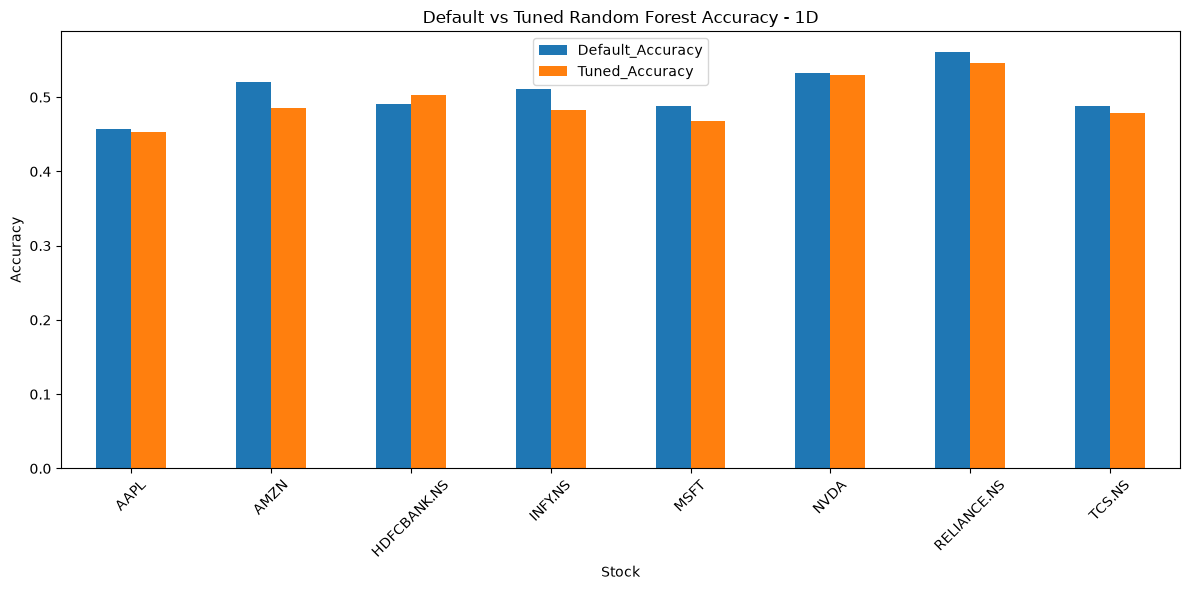

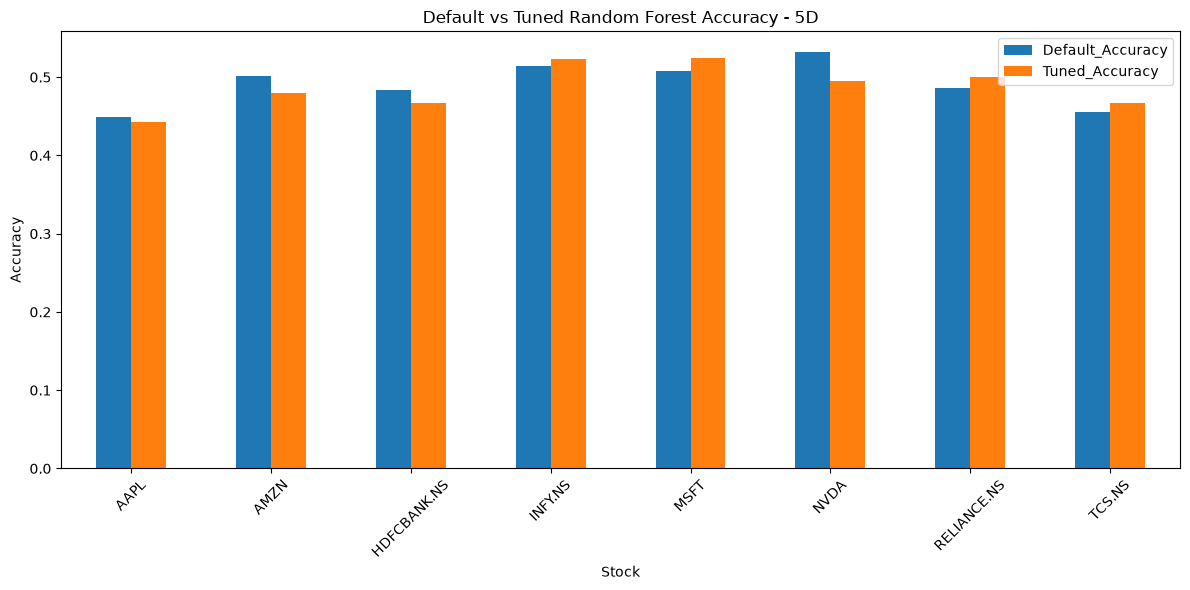

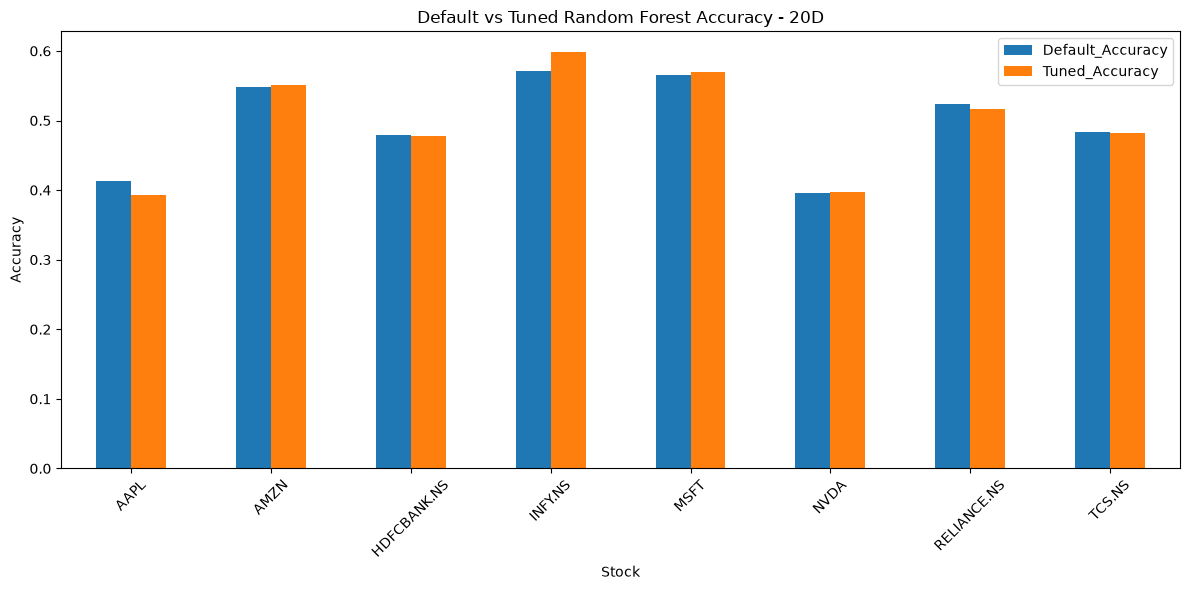

In [9]:
for horizon in horizons:

    plot_df = (
        comparison_df[
            comparison_df["Horizon"] == horizon
        ]
        .set_index("Stock")[
            ["Default_Accuracy", "Tuned_Accuracy"]
        ]
    )

    ax = plot_df.plot(
        kind="bar",
        figsize=(12, 6)
    )

    ax.set_title(
        f"Default vs Tuned Random Forest Accuracy - {horizon}"
    )
    ax.set_xlabel("Stock")
    ax.set_ylabel("Accuracy")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## 10. CV Accuracy — Default vs Tuned

Time-Series CV accuracy is shown separately because it is the validation metric used during model development and later final-model selection.


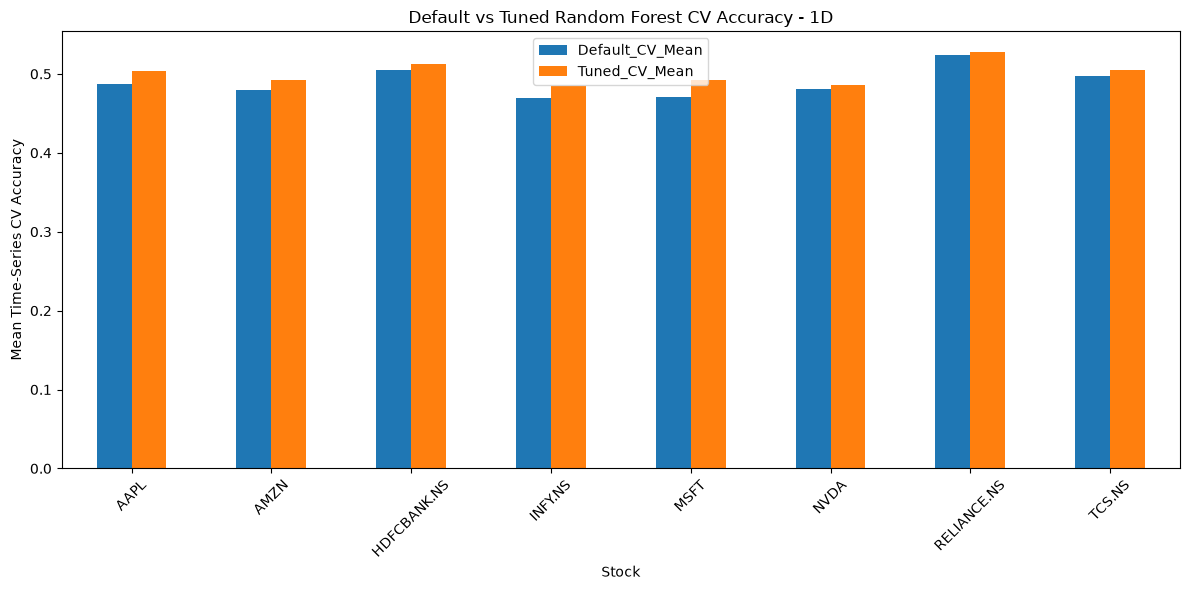

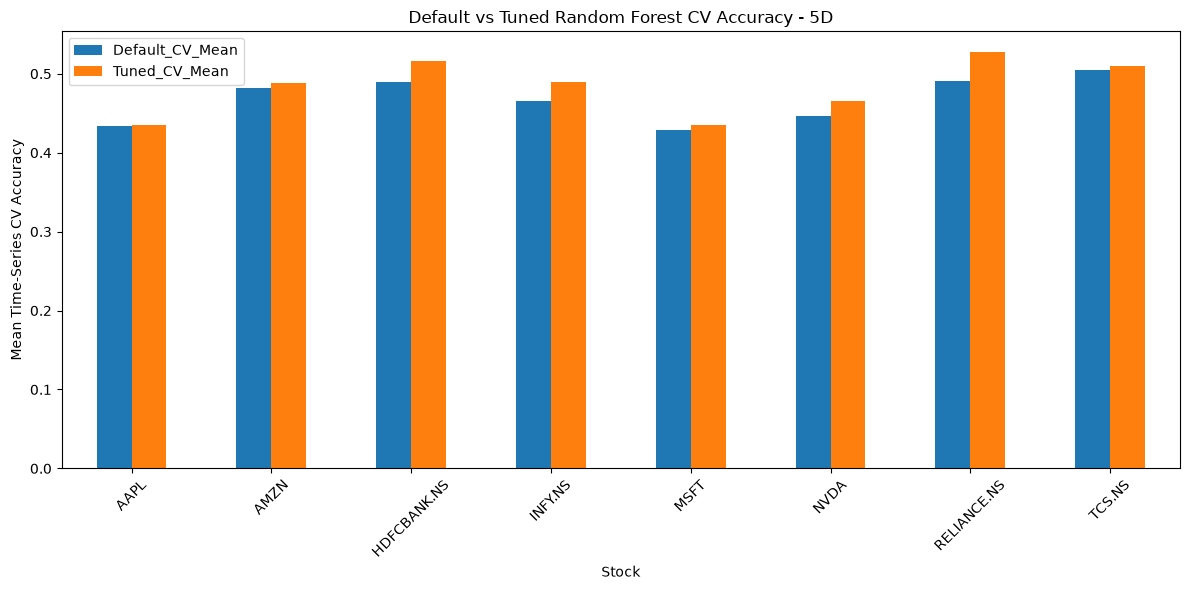

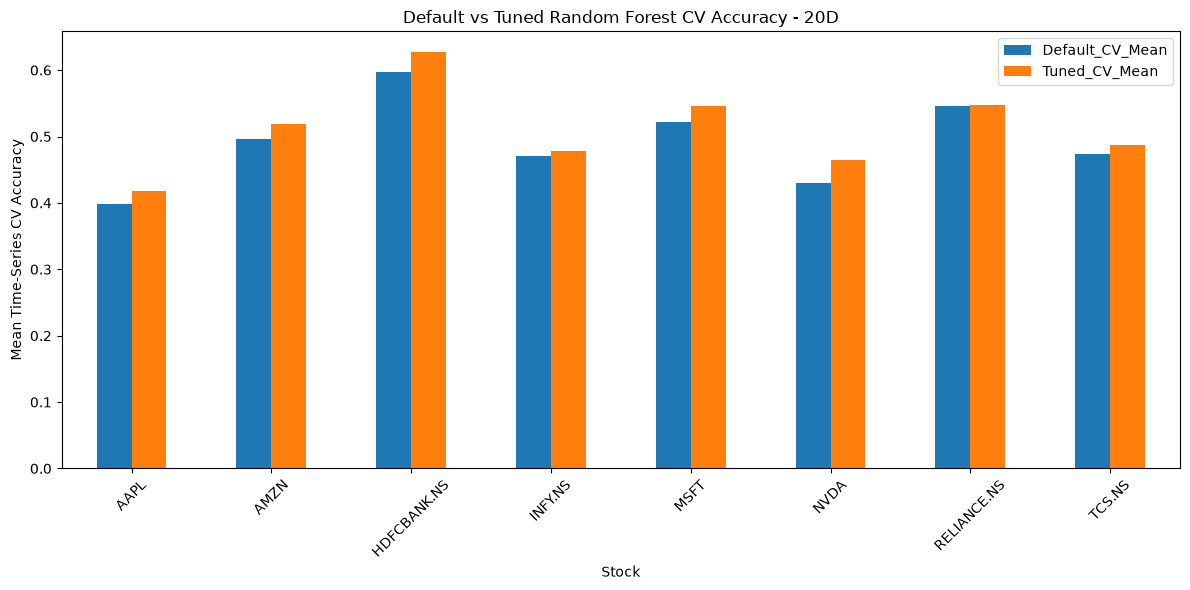

In [10]:
for horizon in horizons:

    plot_df = (
        comparison_df[
            comparison_df["Horizon"] == horizon
        ]
        .set_index("Stock")[
            ["Default_CV_Mean", "Tuned_CV_Mean"]
        ]
    )

    ax = plot_df.plot(
        kind="bar",
        figsize=(12, 6)
    )

    ax.set_title(
        f"Default vs Tuned Random Forest CV Accuracy - {horizon}"
    )
    ax.set_xlabel("Stock")
    ax.set_ylabel("Mean Time-Series CV Accuracy")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## 11. Tuning Improvement Summary

Summarize how tuning changed the test-set and Time-Series CV accuracy for each horizon.


In [11]:
improvement_summary = (
    comparison_df
    .groupby("Horizon")[
        ["Test_Improvement", "CV_Improvement"]
    ]
    .mean()
    .reset_index()
)

display(improvement_summary)


,Horizon,Test_Improvement,CV_Improvement
0,1D,-0.012825,0.010874
1,20D,0.000255,0.019258
2,5D,-0.003848,0.015937


## 12. Save Tuning Outputs

The reusable tuning module already saves the main artifacts.

This notebook additionally saves the comparison table generated during analysis.


In [12]:
comparison_path = "../results/default_vs_tuned_rf.csv"

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    f"Comparison results saved to: {comparison_path}"
)


Comparison results saved to: ../results/default_vs_tuned_rf.csv


In [13]:
best_params_path = "../models/best_rf_params.json"

print(
    f"Best hyperparameters are maintained by the tuning pipeline at: "
    f"{best_params_path}"
)

tuned_results_path = "../results/tuned_rf_results.csv"

print(
    f"Tuned results are maintained by the tuning pipeline at: "
    f"{tuned_results_path}"
)


Best hyperparameters are maintained by the tuning pipeline at: ../models/best_rf_params.json
Tuned results are maintained by the tuning pipeline at: ../results/tuned_rf_results.csv


## Conclusion

Optuna tuning was performed separately for all **8 stocks × 3 prediction horizons**.

The tuning workflow uses `TimeSeriesSplit` on the chronological training portion while keeping the latest 20% of observations untouched for independent evaluation.

The tuned Random Forest models are compared with the default Random Forest using both test-set metrics and Time-Series CV performance.

The optimized parameters and tuning results are saved for use by **Notebook 09 — Final Model Evaluation**.
